# Cross-Lot Generalization: Do Vision Foundation Models Transfer Across Manufacturing Conditions?

This notebook tests whether foundation models (DINOv2, CLIP) generalize better than supervised baselines (ResNet-50) **across semiconductor manufacturing lots**.

**Why this matters:** In real fabs, models trained on historical lots must classify defects on *new* production lots with different process conditions. A random train/test split hides this challenge because both splits contain wafers from the same lots. Splitting by `lotName` reveals the real deployment gap.

**Key question:** Do self-supervised/language-supervised representations transfer better across manufacturing conditions than supervised ImageNet features?

**Dataset:** WM-811K (split by lot, not randomly)  
**Models:** DINOv2 ViT-L/14, CLIP ViT-L/14, ResNet-50 (ImageNet)

## 1. Setup & Installation

In [4]:
!pip install umap-learn timm open_clip_torch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 18.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00


In [5]:
import os
import pickle
import warnings
import time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
import torchvision.models as models

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 2. Dataset Loading & Lot-Based Splitting

The critical difference from the main notebook: instead of `train_test_split(..., stratify=labels)`, we split by **lot number**. Wafers from the same lot share manufacturing conditions (recipe, chamber, consumable wear). A model that only works on lots it's seen during training is useless in production.

In [6]:
!find /kaggle/input -name "*.pkl" -o -name "*.pickle" 

/kaggle/input/datasets/qingyi/wm811k-wafer-map/LSWMD.pkl


In [7]:
# ============================================================
# Load WM-811K dataset
# ============================================================
# Update this path to match your Kaggle dataset location
DATA_PATH = Path('/kaggle/input/datasets/qingyi/wm811k-wafer-map')
PKL_FILE = DATA_PATH / 'LSWMD.pkl'

assert PKL_FILE.exists(), (
    f"Dataset not found at {PKL_FILE}. "
    f"Run the find command above and update DATA_PATH."
)

print("Loading WM-811K dataset...")
df = pd.read_pickle(PKL_FILE)
print(f"Total wafer maps: {len(df):,}")
print(f"Columns: {list(df.columns)}")

# Extract labels
df['failureLabel'] = df['failureType'].apply(
    lambda x: x[0][0] if isinstance(x, np.ndarray) and x.size > 0 else 'unlabeled'
)

DEFECT_CLASSES = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring',
                  'Loc', 'Near-full', 'Random', 'Scratch', 'none']

df_labeled = df[df['failureLabel'].isin(DEFECT_CLASSES)].copy()
df_labeled = df_labeled.reset_index(drop=True)

print(f"\nLabeled wafer maps: {len(df_labeled):,}")
print(f"\nClass distribution:")
print(df_labeled['failureLabel'].value_counts().to_string())

Loading WM-811K dataset...
Total wafer maps: 811,457
Columns: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']

Labeled wafer maps: 172,950

Class distribution:
failureLabel
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149


Total unique lots: 10,762
Wafers per lot — min: 1, max: 25, median: 23, mean: 16.1


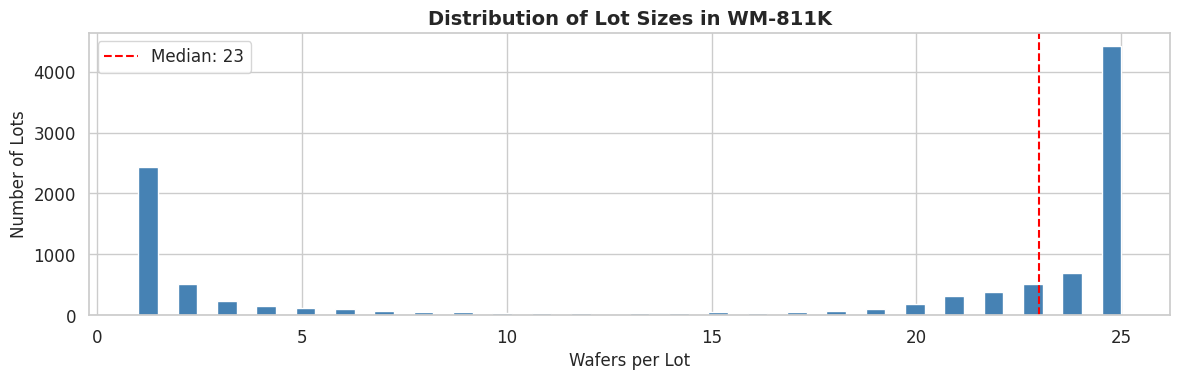

In [8]:
# ============================================================
# Analyze lot structure
# ============================================================
# Extract lot names — this is what we split on
lot_names = df_labeled['lotName'].apply(
    lambda x: x[0] if isinstance(x, np.ndarray) and x.size > 0 else str(x)
)
df_labeled['lot'] = lot_names

unique_lots = df_labeled['lot'].unique()
wafers_per_lot = df_labeled.groupby('lot').size()

print(f"Total unique lots: {len(unique_lots):,}")
print(f"Wafers per lot — min: {wafers_per_lot.min()}, max: {wafers_per_lot.max()}, "
      f"median: {wafers_per_lot.median():.0f}, mean: {wafers_per_lot.mean():.1f}")

# Show lot size distribution
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(wafers_per_lot.values, bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('Wafers per Lot', fontsize=12)
ax.set_ylabel('Number of Lots', fontsize=12)
ax.set_title('Distribution of Lot Sizes in WM-811K', fontsize=14, fontweight='bold')
ax.axvline(wafers_per_lot.median(), color='red', linestyle='--', label=f'Median: {wafers_per_lot.median():.0f}')
ax.legend()
plt.tight_layout()
plt.savefig('lot_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ============================================================
# Lot-Based Train/Test Split
# ============================================================
# We assign entire lots to either train or test — no lot appears
# in both. This simulates deploying a model on new production lots
# it has never seen.
# ============================================================

np.random.seed(42)

# Shuffle lots and split ~80/20
shuffled_lots = np.random.permutation(unique_lots)
split_point = int(len(shuffled_lots) * 0.8)
train_lots = set(shuffled_lots[:split_point])
test_lots = set(shuffled_lots[split_point:])

train_mask = df_labeled['lot'].isin(train_lots)
test_mask = df_labeled['lot'].isin(test_lots)

df_train = df_labeled[train_mask].reset_index(drop=True)
df_test = df_labeled[test_mask].reset_index(drop=True)

print(f"Train lots: {len(train_lots):,} | Test lots: {len(test_lots):,}")
print(f"Train samples: {len(df_train):,} | Test samples: {len(df_test):,}")
print(f"\nTrain class distribution:")
print(df_train['failureLabel'].value_counts().to_string())
print(f"\nTest class distribution:")
print(df_test['failureLabel'].value_counts().to_string())

# Check for class coverage issues
train_classes = set(df_train['failureLabel'].unique())
test_classes = set(df_test['failureLabel'].unique())
missing = test_classes - train_classes
if missing:
    print(f"\n⚠ WARNING: Classes in test but not train: {missing}")
    print("Some rare classes may not appear in all lot splits.")
else:
    print(f"\n✓ All {len(test_classes)} classes present in both splits.")

Train lots: 8,609 | Test lots: 2,153
Train samples: 138,024 | Test samples: 34,926

Train class distribution:
failureLabel
none         117252
Edge-Ring      7993
Edge-Loc       4191
Center         3495
Loc            2868
Scratch         932
Random          699
Donut           474
Near-full       120

Test class distribution:
failureLabel
none         30179
Edge-Ring     1687
Edge-Loc       998
Center         799
Loc            725
Scratch        261
Random         167
Donut           81
Near-full       29

✓ All 9 classes present in both splits.


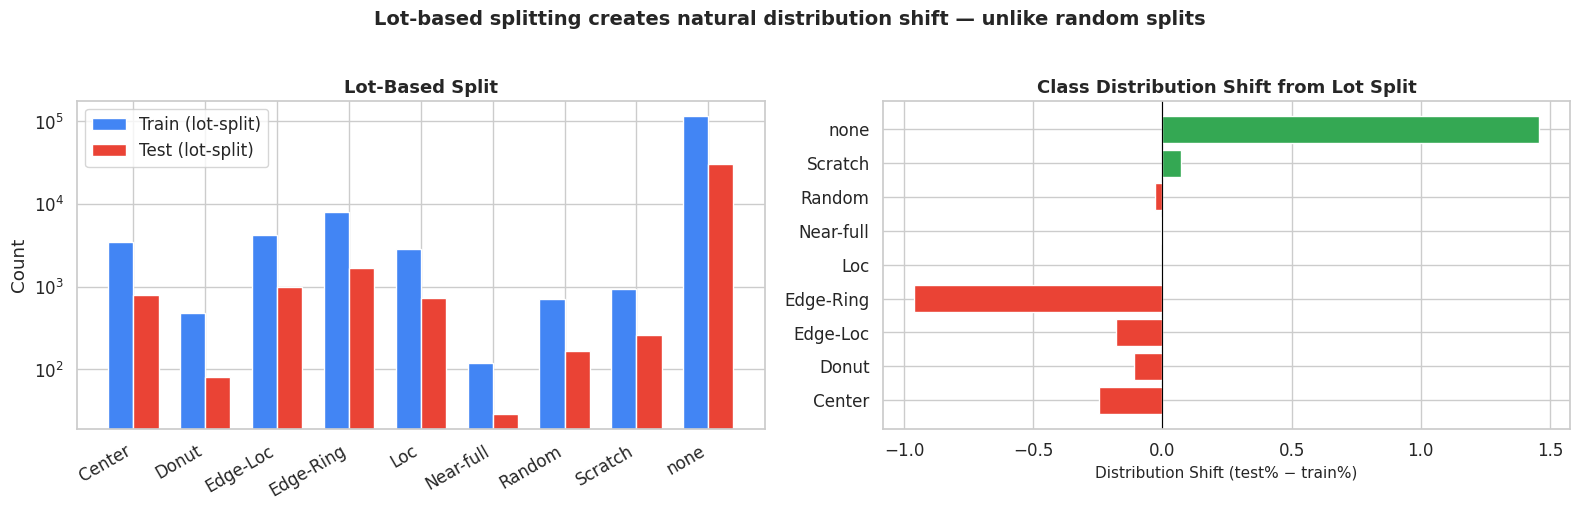

Notice: lot-based splits create class distribution shifts because
different lots have different defect profiles. This is realistic —
in production, new lots won't match historical defect distributions.


In [10]:
# ============================================================
# Compare lot-split vs random-split class distributions
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Lot-based split
train_counts = df_train['failureLabel'].value_counts()
test_counts = df_test['failureLabel'].value_counts()

x = np.arange(len(DEFECT_CLASSES))
width = 0.35

ax1.bar(x - width/2, [train_counts.get(c, 0) for c in DEFECT_CLASSES],
        width, label='Train (lot-split)', color='#4285F4', edgecolor='white')
ax1.bar(x + width/2, [test_counts.get(c, 0) for c in DEFECT_CLASSES],
        width, label='Test (lot-split)', color='#EA4335', edgecolor='white')
ax1.set_xticks(x)
ax1.set_xticklabels(DEFECT_CLASSES, rotation=30, ha='right')
ax1.set_ylabel('Count')
ax1.set_title('Lot-Based Split', fontsize=13, fontweight='bold')
ax1.set_yscale('log')
ax1.legend()

# Show the distribution shift
train_pct = df_train['failureLabel'].value_counts(normalize=True)
test_pct = df_test['failureLabel'].value_counts(normalize=True)

for c in DEFECT_CLASSES:
    t1 = train_pct.get(c, 0) * 100
    t2 = test_pct.get(c, 0) * 100
    shift = t2 - t1
    ax2.barh(c, shift, color='#34A853' if shift > 0 else '#EA4335')

ax2.set_xlabel('Distribution Shift (test% − train%)', fontsize=11)
ax2.set_title('Class Distribution Shift from Lot Split', fontsize=13, fontweight='bold')
ax2.axvline(0, color='black', linewidth=0.8)

plt.suptitle('Lot-based splitting creates natural distribution shift — unlike random splits',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('lot_split_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Notice: lot-based splits create class distribution shifts because")
print("different lots have different defect profiles. This is realistic —")
print("in production, new lots won't match historical defect distributions.")

## 3. Data Preprocessing

In [11]:
class WaferMapDataset(Dataset):
    """PyTorch dataset for WM-811K wafer bin maps."""
    
    COLOR_MAP = np.array([
        [45, 45, 45],      # background: dark gray
        [232, 232, 232],    # pass: light gray
        [211, 47, 47],      # fail: red
    ], dtype=np.uint8)
    
    def __init__(self, wafer_maps, labels, label_to_idx, img_size=224, transform=None):
        self.wafer_maps = wafer_maps
        self.labels = labels
        self.label_to_idx = label_to_idx
        self.img_size = img_size
        self.transform = transform or self._default_transform()
    
    def _default_transform(self):
        return transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((self.img_size, self.img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])
    
    def _wafer_to_rgb(self, wafer_map):
        wafer_clipped = np.clip(wafer_map.astype(int), 0, 2)
        return self.COLOR_MAP[wafer_clipped]
    
    def __len__(self):
        return len(self.wafer_maps)
    
    def __getitem__(self, idx):
        wafer_map = self.wafer_maps[idx]
        label = self.label_to_idx[self.labels[idx]]
        rgb = self._wafer_to_rgb(wafer_map)
        img = self.transform(rgb)
        return img, label


# Build label mapping
label_to_idx = {label: idx for idx, label in enumerate(DEFECT_CLASSES)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}
NUM_CLASSES = len(DEFECT_CLASSES)

# Create datasets from lot-based split
IMG_SIZE = 224
BATCH_SIZE = 64

train_maps = df_train['waferMap'].values
train_labels = df_train['failureLabel'].values
test_maps = df_test['waferMap'].values
test_labels = df_test['failureLabel'].values

train_dataset = WaferMapDataset(train_maps, train_labels, label_to_idx, img_size=IMG_SIZE)
test_dataset = WaferMapDataset(test_maps, test_labels, label_to_idx, img_size=IMG_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"Train: {len(train_dataset):,} samples from {len(train_lots):,} lots")
print(f"Test:  {len(test_dataset):,} samples from {len(test_lots):,} lots")
print(f"Zero lot overlap between train and test.")

Train: 138,024 samples from 8,609 lots
Test:  34,926 samples from 2,153 lots
Zero lot overlap between train and test.


## 4. Load Models

Same three models as the main notebook — all used as **frozen feature extractors**:
- **DINOv2 ViT-L/14** (self-supervised, Meta)
- **CLIP ViT-L/14** (language-supervised, OpenAI)
- **ResNet-50** (supervised ImageNet baseline)

In [12]:
# ============================================================
# Load DINOv2 ViT-L/14
# ============================================================
print("Loading DINOv2 ViT-L/14...")
dinov2_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitl14')
dinov2_model = dinov2_model.to(DEVICE)
dinov2_model.eval()
dinov2_embed_dim = dinov2_model.embed_dim
print(f"DINOv2 loaded — embedding dim: {dinov2_embed_dim}")
print(f"Parameters: {sum(p.numel() for p in dinov2_model.parameters()):,}")

Loading DINOv2 ViT-L/14...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitl14/dinov2_vitl14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitl14_pretrain.pth


100%|██████████| 1.13G/1.13G [00:03<00:00, 362MB/s]


DINOv2 loaded — embedding dim: 1024
Parameters: 304,368,640


In [13]:
import open_clip

# ============================================================
# Load CLIP ViT-L/14
# ============================================================
print("Loading CLIP ViT-L/14...")
clip_raw, _, _ = open_clip.create_model_and_transforms('ViT-L-14', pretrained='openai')
clip_raw = clip_raw.to(DEVICE)
clip_raw.eval()

class CLIPWrapper(nn.Module):
    def __init__(self, clip_model):
        super().__init__()
        self.model = clip_model
        self.embed_dim = clip_model.visual.output_dim
    def forward(self, x):
        return self.model.encode_image(x)

clip_model = CLIPWrapper(clip_raw)
clip_embed_dim = clip_model.embed_dim
print(f"CLIP ViT-L loaded — embedding dim: {clip_embed_dim}")
print(f"Parameters: {sum(p.numel() for p in clip_model.parameters()):,}")

Loading CLIP ViT-L/14...


open_clip_model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

CLIP ViT-L loaded — embedding dim: 768
Parameters: 427,616,513


In [14]:
# ============================================================
# Load ResNet-50 (supervised ImageNet baseline)
# ============================================================
print("Loading ResNet-50 (ImageNet pretrained)...")
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
resnet_backbone = nn.Sequential(*list(resnet.children())[:-1])

class ResNetWrapper(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.embed_dim = 2048
    def forward(self, x):
        return self.backbone(x).flatten(1)

resnet_model = ResNetWrapper(resnet_backbone).to(DEVICE)
resnet_model.eval()
print(f"ResNet-50 loaded — embedding dim: 2048")
print(f"Parameters: {sum(p.numel() for p in resnet_model.parameters()):,}")

Loading ResNet-50 (ImageNet pretrained)...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s] 


ResNet-50 loaded — embedding dim: 2048
Parameters: 23,508,032


## 5. Feature Extraction

Extract frozen embeddings from all three models on the **lot-split** train/test sets.

In [15]:
@torch.no_grad()
def extract_features(model, dataloader, device, model_name='model'):
    """Extract features from a frozen model."""
    all_features = []
    all_labels = []
    
    start = time.time()
    total_batches = len(dataloader)
    
    for batch_idx, (images, labels) in enumerate(dataloader):
        images = images.to(device)
        features = model(images).float()
        
        if isinstance(features, dict):
            features = features.get('last_hidden_state', features.get('pooler_output'))
            if features.dim() == 3:
                features = features[:, 0]
        
        all_features.append(features.cpu().numpy())
        all_labels.append(labels.numpy())
        
        if (batch_idx + 1) % 50 == 0 or batch_idx == total_batches - 1:
            elapsed = time.time() - start
            print(f"  [{model_name}] Batch {batch_idx+1}/{total_batches} ({elapsed:.1f}s)")
    
    elapsed = time.time() - start
    features = np.concatenate(all_features, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    print(f"  [{model_name}] Done — {features.shape[0]:,} samples, {features.shape[1]}d, {elapsed:.1f}s")
    return features, labels, elapsed

In [16]:
# ============================================================
# Extract features from all three models
# ============================================================
print("="*60)
print("Extracting features with DINOv2...")
print("="*60)
train_feats_dinov2, train_labels_arr, dinov2_train_time = extract_features(
    dinov2_model, train_loader, DEVICE, 'DINOv2')
test_feats_dinov2, test_labels_arr, dinov2_test_time = extract_features(
    dinov2_model, test_loader, DEVICE, 'DINOv2')

print(f"\n{'='*60}")
print("Extracting features with CLIP...")
print("="*60)
train_feats_clip, _, clip_train_time = extract_features(
    clip_model, train_loader, DEVICE, 'CLIP')
test_feats_clip, _, clip_test_time = extract_features(
    clip_model, test_loader, DEVICE, 'CLIP')

print(f"\n{'='*60}")
print("Extracting features with ResNet-50...")
print("="*60)
train_feats_resnet, _, resnet_train_time = extract_features(
    resnet_model, train_loader, DEVICE, 'ResNet-50')
test_feats_resnet, _, resnet_test_time = extract_features(
    resnet_model, test_loader, DEVICE, 'ResNet-50')

# Save features
for name, train_f, test_f in [('dinov2', train_feats_dinov2, test_feats_dinov2),
                                ('clip', train_feats_clip, test_feats_clip),
                                ('resnet', train_feats_resnet, test_feats_resnet)]:
    np.save(f'crosslot_train_feats_{name}.npy', train_f)
    np.save(f'crosslot_test_feats_{name}.npy', test_f)
print("\nAll features saved to disk.")

Extracting features with DINOv2...
  [DINOv2] Batch 50/2157 (154.6s)
  [DINOv2] Batch 100/2157 (318.1s)
  [DINOv2] Batch 150/2157 (481.4s)
  [DINOv2] Batch 200/2157 (644.6s)
  [DINOv2] Batch 250/2157 (808.6s)
  [DINOv2] Batch 300/2157 (972.6s)
  [DINOv2] Batch 350/2157 (1135.9s)
  [DINOv2] Batch 400/2157 (1299.8s)
  [DINOv2] Batch 450/2157 (1462.9s)
  [DINOv2] Batch 500/2157 (1626.8s)
  [DINOv2] Batch 550/2157 (1790.6s)
  [DINOv2] Batch 600/2157 (1954.2s)
  [DINOv2] Batch 650/2157 (2117.7s)
  [DINOv2] Batch 700/2157 (2280.7s)
  [DINOv2] Batch 750/2157 (2444.3s)
  [DINOv2] Batch 800/2157 (2607.0s)
  [DINOv2] Batch 850/2157 (2770.9s)
  [DINOv2] Batch 900/2157 (2934.7s)
  [DINOv2] Batch 950/2157 (3098.1s)
  [DINOv2] Batch 1000/2157 (3261.6s)
  [DINOv2] Batch 1050/2157 (3425.6s)
  [DINOv2] Batch 1100/2157 (3589.0s)
  [DINOv2] Batch 1150/2157 (3751.8s)
  [DINOv2] Batch 1200/2157 (3915.7s)
  [DINOv2] Batch 1250/2157 (4079.1s)
  [DINOv2] Batch 1300/2157 (4242.7s)
  [DINOv2] Batch 1350/2157 (4

## 6. Cross-Lot Linear Probe Evaluation

This is where the cross-lot split matters. A model that scores 98% on a random split but drops to 85% on a lot split is **memorizing lot-specific patterns**, not learning generalizable defect features.

In [17]:
def train_and_evaluate_probe(train_feats, test_feats, train_labels, test_labels, model_name):
    """Train logistic regression on frozen features and evaluate."""
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_feats)
    X_test = scaler.transform(test_feats)
    
    print(f"\nTraining linear probe on {model_name} features...")
    start = time.time()
    
    clf = LogisticRegression(
        max_iter=1000, C=1.0, solver='lbfgs',
        multi_class='multinomial', random_state=42, n_jobs=-1
    )
    clf.fit(X_train, train_labels)
    train_time = time.time() - start
    
    train_pred = clf.predict(X_train)
    test_pred = clf.predict(X_test)
    
    results = {
        'model': model_name,
        'train_acc': accuracy_score(train_labels, train_pred),
        'test_acc': accuracy_score(test_labels, test_pred),
        'test_f1_macro': f1_score(test_labels, test_pred, average='macro'),
        'test_f1_weighted': f1_score(test_labels, test_pred, average='weighted'),
        'train_time': train_time,
        'predictions': test_pred,
        'gap': accuracy_score(train_labels, train_pred) - accuracy_score(test_labels, test_pred),
    }
    
    print(f"  Train acc: {results['train_acc']:.4f}")
    print(f"  Test acc:  {results['test_acc']:.4f}")
    print(f"  ★ Generalization gap: {results['gap']:.4f} ({results['gap']*100:.1f}pp)")
    print(f"  Test F1 (macro): {results['test_f1_macro']:.4f}")
    
    return results


results_dinov2 = train_and_evaluate_probe(
    train_feats_dinov2, test_feats_dinov2, train_labels_arr, test_labels_arr, 'DINOv2')
results_clip = train_and_evaluate_probe(
    train_feats_clip, test_feats_clip, train_labels_arr, test_labels_arr, 'CLIP')
results_resnet = train_and_evaluate_probe(
    train_feats_resnet, test_feats_resnet, train_labels_arr, test_labels_arr, 'ResNet-50')


Training linear probe on DINOv2 features...
  Train acc: 0.9868
  Test acc:  0.9718
  ★ Generalization gap: 0.0150 (1.5pp)
  Test F1 (macro): 0.8409

Training linear probe on CLIP features...
  Train acc: 0.9774
  Test acc:  0.9680
  ★ Generalization gap: 0.0095 (0.9pp)
  Test F1 (macro): 0.8361

Training linear probe on ResNet-50 features...
  Train acc: 0.9654
  Test acc:  0.9403
  ★ Generalization gap: 0.0251 (2.5pp)
  Test F1 (macro): 0.7068


## 7. Results: Cross-Lot Generalization

### 7.1 Generalization Gap

The **generalization gap** (train accuracy − test accuracy) reveals how much each model overfits to lot-specific patterns. A smaller gap means better cross-lot transfer.

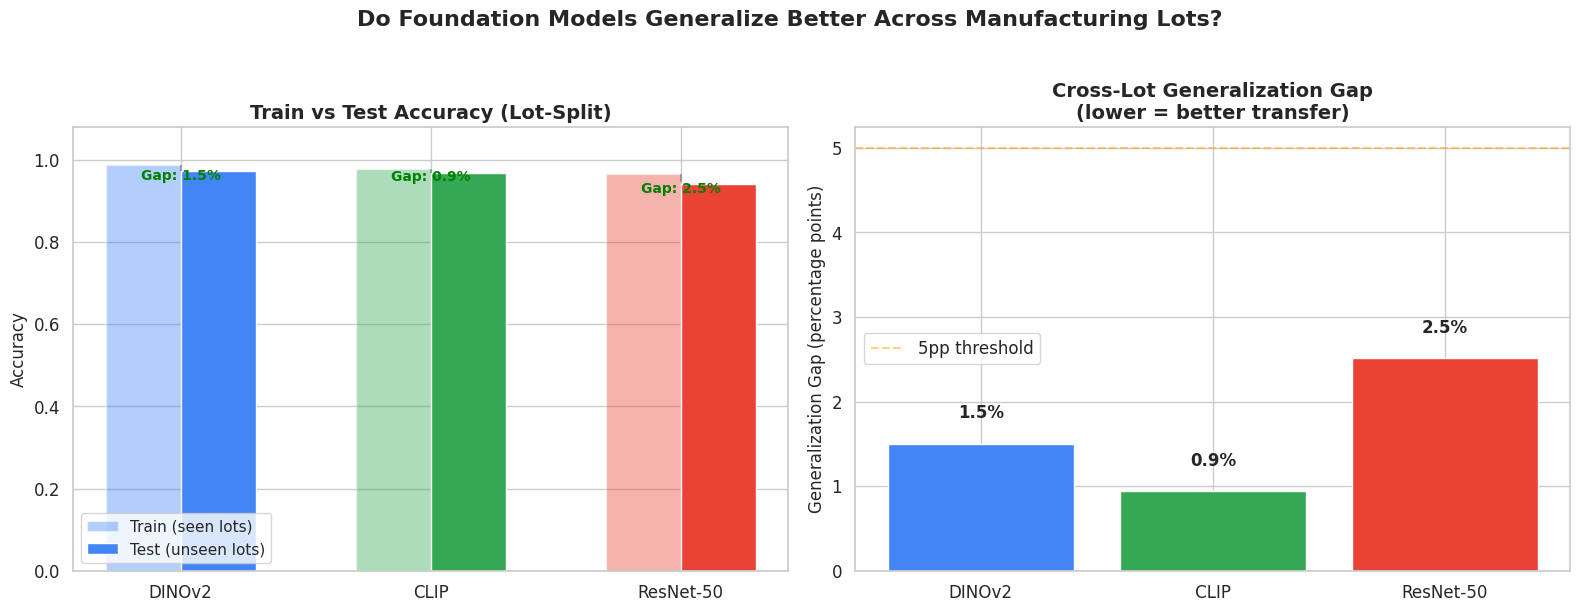

In [18]:
# ============================================================
# Generalization Gap Comparison
# ============================================================
model_names = ['DINOv2', 'CLIP', 'ResNet-50']
all_results = [results_dinov2, results_clip, results_resnet]
colors = ['#4285F4', '#34A853', '#EA4335']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Train vs Test accuracy
x = np.arange(len(model_names))
width = 0.3

train_accs = [r['train_acc'] for r in all_results]
test_accs = [r['test_acc'] for r in all_results]

bars1 = ax1.bar(x - width/2, train_accs, width, label='Train (seen lots)',
                color=[c for c in colors], alpha=0.4, edgecolor='white')
bars2 = ax1.bar(x + width/2, test_accs, width, label='Test (unseen lots)',
                color=[c for c in colors], edgecolor='white')

for i, (train, test) in enumerate(zip(train_accs, test_accs)):
    gap = train - test
    ax1.annotate(f'Gap: {gap:.1%}', xy=(i, min(train, test) - 0.02),
                 fontsize=10, ha='center', fontweight='bold',
                 color='red' if gap > 0.05 else 'green')
    ax1.plot([i - width/2 + width/2, i + width/2 + width/2 - width],
             [train, test], 'k--', alpha=0.3)

ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Train vs Test Accuracy (Lot-Split)', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, fontsize=12)
ax1.legend(fontsize=11)
ax1.set_ylim(0, 1.08)

# Right: Generalization gap bar chart
gaps = [r['gap'] for r in all_results]
bars = ax2.bar(model_names, [g * 100 for g in gaps], color=colors, edgecolor='white')
for bar, gap in zip(bars, gaps):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{gap:.1%}', ha='center', fontweight='bold', fontsize=12)

ax2.set_ylabel('Generalization Gap (percentage points)', fontsize=12)
ax2.set_title('Cross-Lot Generalization Gap\n(lower = better transfer)', fontsize=14, fontweight='bold')
ax2.axhline(y=5, color='orange', linestyle='--', alpha=0.5, label='5pp threshold')
ax2.legend()

plt.suptitle('Do Foundation Models Generalize Better Across Manufacturing Lots?',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('crosslot_generalization_gap.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 Per-Class Cross-Lot Performance

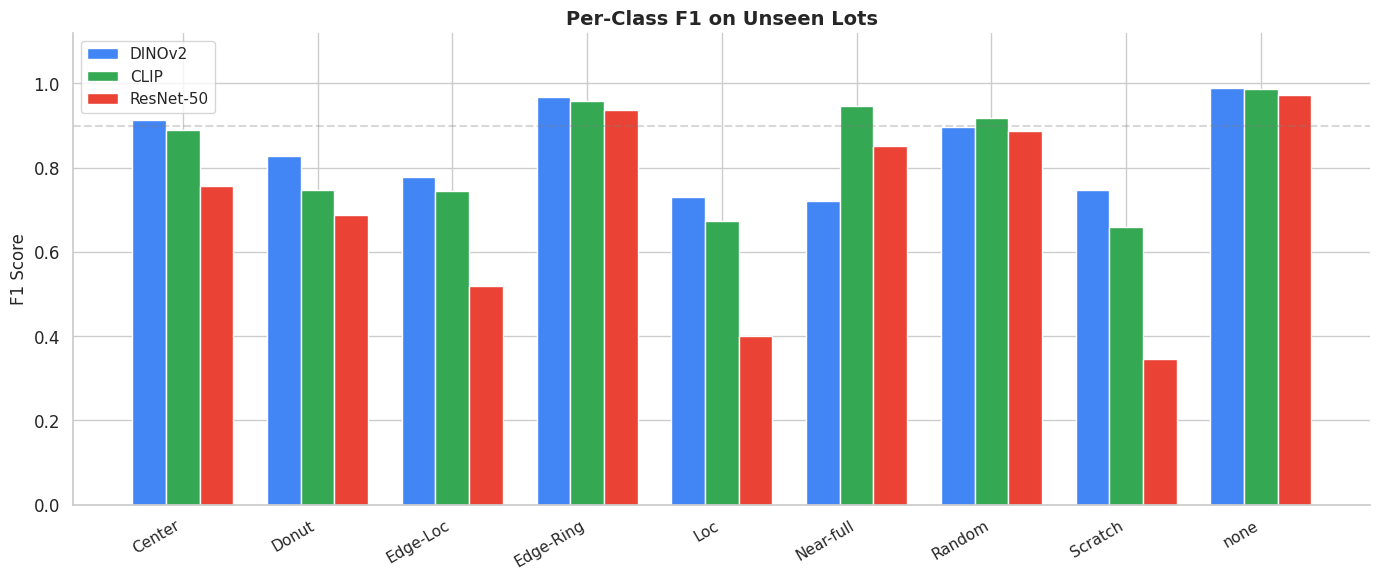

Watch the rare classes (Donut, Near-full) — these are most likely
to degrade on unseen lots because there are fewer examples to learn from.


In [19]:
# ============================================================
# Per-Class F1 on Unseen Lots
# ============================================================
f1_dinov2 = f1_score(test_labels_arr, results_dinov2['predictions'],
                     labels=range(NUM_CLASSES), average=None)
f1_clip = f1_score(test_labels_arr, results_clip['predictions'],
                   labels=range(NUM_CLASSES), average=None)
f1_resnet = f1_score(test_labels_arr, results_resnet['predictions'],
                     labels=range(NUM_CLASSES), average=None)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(NUM_CLASSES)
width = 0.25

ax.bar(x - width, f1_dinov2, width, label='DINOv2', color='#4285F4', edgecolor='white')
ax.bar(x, f1_clip, width, label='CLIP', color='#34A853', edgecolor='white')
ax.bar(x + width, f1_resnet, width, label='ResNet-50', color='#EA4335', edgecolor='white')

ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Per-Class F1 on Unseen Lots', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(DEFECT_CLASSES, rotation=30, ha='right', fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.12)
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('crosslot_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

print("Watch the rare classes (Donut, Near-full) — these are most likely")
print("to degrade on unseen lots because there are fewer examples to learn from.")

### 7.3 Confusion Matrices (Unseen Lots)

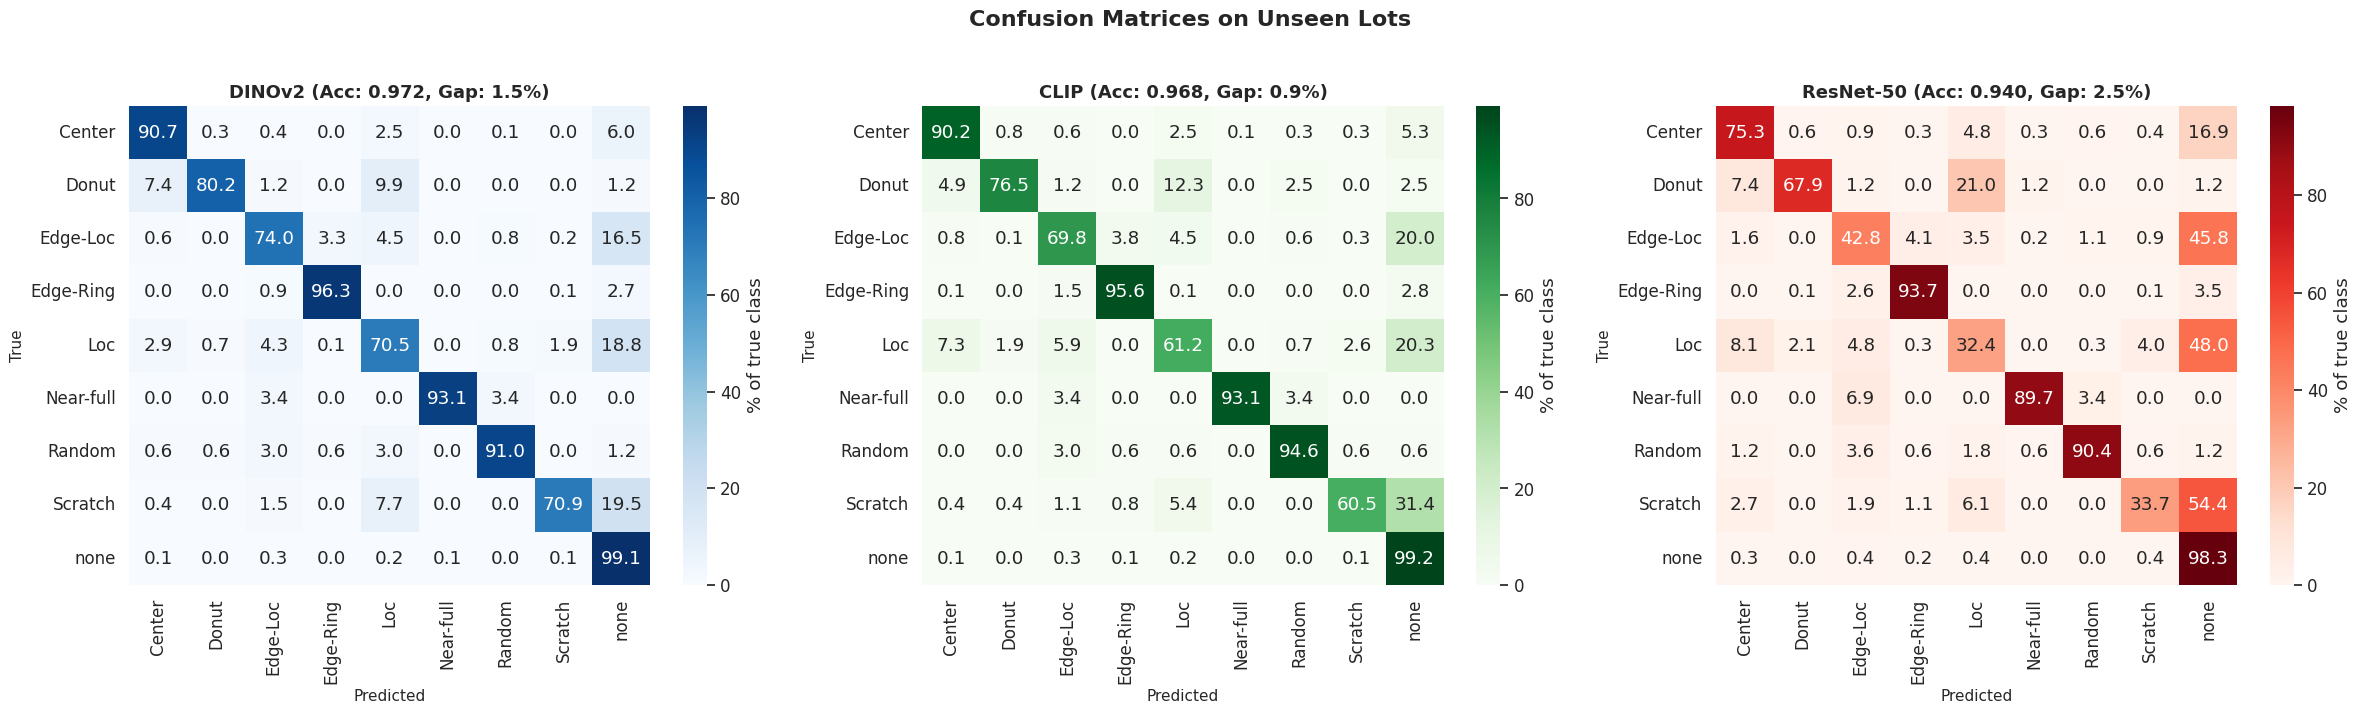

In [20]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 7))

for ax, results, title, cmap in [
    (ax1, results_dinov2, 'DINOv2', 'Blues'),
    (ax2, results_clip, 'CLIP', 'Greens'),
    (ax3, results_resnet, 'ResNet-50', 'Reds'),
]:
    cm = confusion_matrix(test_labels_arr, results['predictions'])
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap=cmap,
                xticklabels=DEFECT_CLASSES, yticklabels=DEFECT_CLASSES,
                ax=ax, cbar_kws={'label': '% of true class'})
    ax.set_title(f'{title} (Acc: {results["test_acc"]:.3f}, Gap: {results["gap"]:.1%})',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)

plt.suptitle('Confusion Matrices on Unseen Lots', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('crosslot_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.4 Few-Shot Learning Across Lots

How many labeled examples from *seen lots* does each model need to generalize to *unseen lots*? This is the real-world question: if you label 50 wafers from your current lots, how well will the model work on next month's production?

In [21]:
def few_shot_evaluation(train_feats, test_feats, train_labels, test_labels,
                        shots_list, model_name, n_trials=5):
    """Few-shot evaluation with lot-split data."""
    results = {'shots': [], 'acc_mean': [], 'acc_std': [],
               'f1_mean': [], 'f1_std': []}
    
    scaler = StandardScaler()
    X_train_full = scaler.fit_transform(train_feats)
    X_test = scaler.transform(test_feats)
    
    unique_labels = np.unique(train_labels)
    
    for n_shots in shots_list:
        trial_accs = []
        trial_f1s = []
        
        for trial in range(n_trials):
            selected_idx = []
            rng = np.random.RandomState(trial * 1000 + n_shots)
            
            for label in unique_labels:
                label_idx = np.where(train_labels == label)[0]
                n_available = min(n_shots, len(label_idx))
                chosen = rng.choice(label_idx, n_available, replace=False)
                selected_idx.extend(chosen)
            
            X_sub = X_train_full[selected_idx]
            y_sub = train_labels[selected_idx]
            
            clf = LogisticRegression(
                max_iter=1000, C=1.0, solver='lbfgs',
                multi_class='multinomial', random_state=42
            )
            clf.fit(X_sub, y_sub)
            
            pred = clf.predict(X_test)
            trial_accs.append(accuracy_score(test_labels, pred))
            trial_f1s.append(f1_score(test_labels, pred, average='macro'))
        
        results['shots'].append(n_shots)
        results['acc_mean'].append(np.mean(trial_accs))
        results['acc_std'].append(np.std(trial_accs))
        results['f1_mean'].append(np.mean(trial_f1s))
        results['f1_std'].append(np.std(trial_f1s))
        
        print(f"  [{model_name}] {n_shots:>5} shots → "
              f"Acc: {np.mean(trial_accs):.4f} ± {np.std(trial_accs):.4f}")
    
    return results


SHOTS_LIST = [5, 10, 20, 50, 100, 200, 500, 1000]

print("Few-shot evaluation on LOT-SPLIT data...\n")

print("DINOv2:")
fewshot_dinov2 = few_shot_evaluation(
    train_feats_dinov2, test_feats_dinov2, train_labels_arr, test_labels_arr,
    SHOTS_LIST, 'DINOv2')

print("\nCLIP:")
fewshot_clip = few_shot_evaluation(
    train_feats_clip, test_feats_clip, train_labels_arr, test_labels_arr,
    SHOTS_LIST, 'CLIP')

print("\nResNet-50:")
fewshot_resnet = few_shot_evaluation(
    train_feats_resnet, test_feats_resnet, train_labels_arr, test_labels_arr,
    SHOTS_LIST, 'ResNet-50')

Few-shot evaluation on LOT-SPLIT data...

DINOv2:
  [DINOv2]     5 shots → Acc: 0.5688 ± 0.0996
  [DINOv2]    10 shots → Acc: 0.7399 ± 0.0532
  [DINOv2]    20 shots → Acc: 0.7893 ± 0.0235
  [DINOv2]    50 shots → Acc: 0.8525 ± 0.0281
  [DINOv2]   100 shots → Acc: 0.8576 ± 0.0106
  [DINOv2]   200 shots → Acc: 0.8830 ± 0.0038
  [DINOv2]   500 shots → Acc: 0.8804 ± 0.0074
  [DINOv2]  1000 shots → Acc: 0.8940 ± 0.0039

CLIP:
  [CLIP]     5 shots → Acc: 0.5518 ± 0.1008
  [CLIP]    10 shots → Acc: 0.7360 ± 0.0510
  [CLIP]    20 shots → Acc: 0.7703 ± 0.0358
  [CLIP]    50 shots → Acc: 0.8332 ± 0.0307
  [CLIP]   100 shots → Acc: 0.8460 ± 0.0103
  [CLIP]   200 shots → Acc: 0.8479 ± 0.0119
  [CLIP]   500 shots → Acc: 0.8486 ± 0.0107
  [CLIP]  1000 shots → Acc: 0.8541 ± 0.0040

ResNet-50:
  [ResNet-50]     5 shots → Acc: 0.4011 ± 0.1554
  [ResNet-50]    10 shots → Acc: 0.4734 ± 0.0446
  [ResNet-50]    20 shots → Acc: 0.5802 ± 0.0721
  [ResNet-50]    50 shots → Acc: 0.6361 ± 0.0690
  [ResNet-50]  

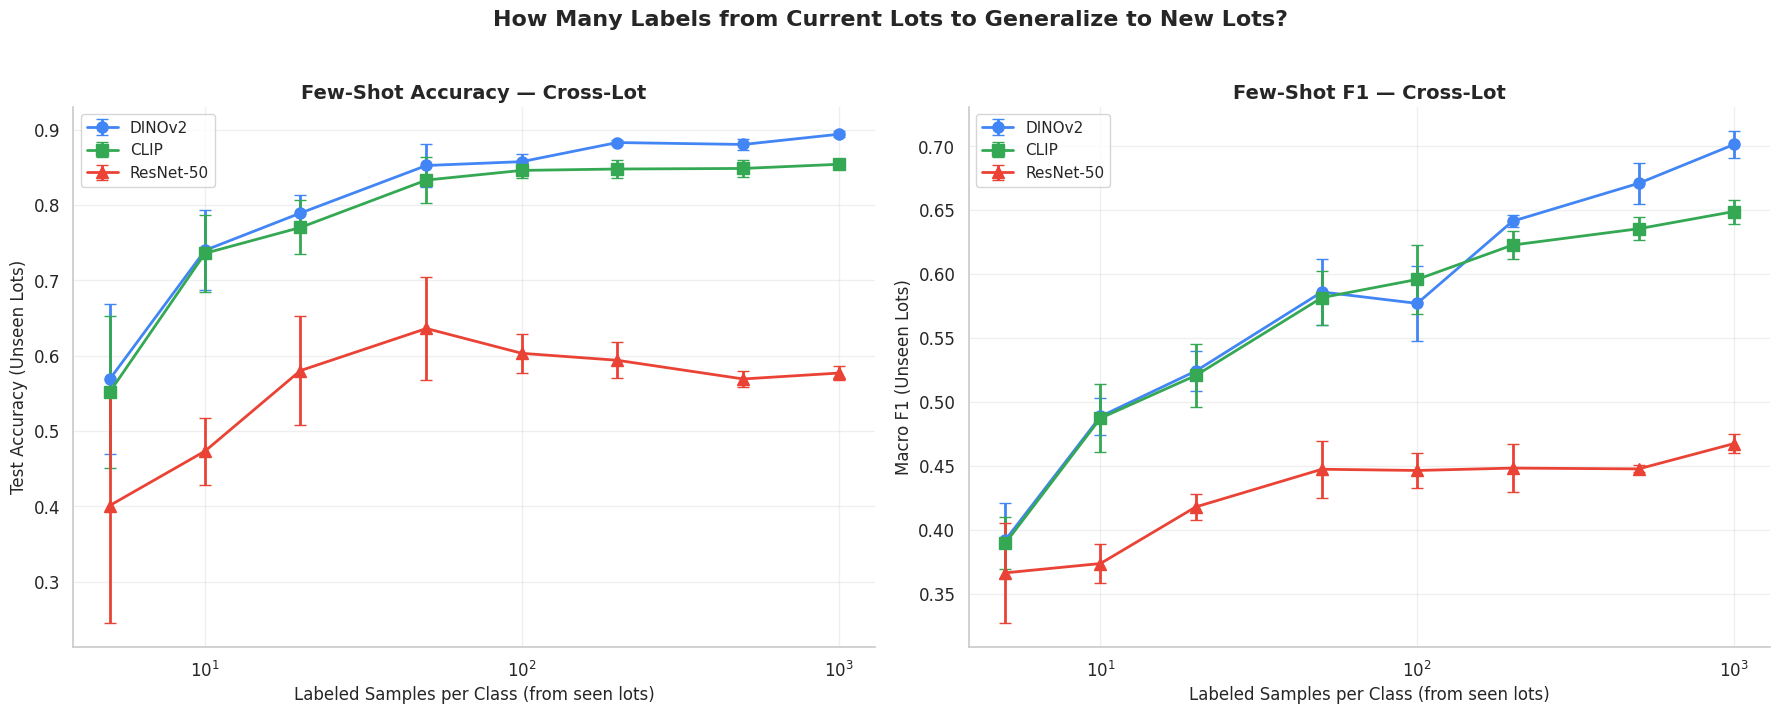

In [22]:
# ============================================================
# Three-Way Few-Shot Curves (Lot-Split)
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

for fewshot, name, color, marker in [
    (fewshot_dinov2, 'DINOv2', '#4285F4', 'o'),
    (fewshot_clip, 'CLIP', '#34A853', 's'),
    (fewshot_resnet, 'ResNet-50', '#EA4335', '^'),
]:
    ax1.errorbar(fewshot['shots'], fewshot['acc_mean'], yerr=fewshot['acc_std'],
                 marker=marker, linewidth=2, capsize=4, label=name, color=color, markersize=8)
    ax2.errorbar(fewshot['shots'], fewshot['f1_mean'], yerr=fewshot['f1_std'],
                 marker=marker, linewidth=2, capsize=4, label=name, color=color, markersize=8)

for ax, ylabel, title in [
    (ax1, 'Test Accuracy (Unseen Lots)', 'Few-Shot Accuracy — Cross-Lot'),
    (ax2, 'Macro F1 (Unseen Lots)', 'Few-Shot F1 — Cross-Lot'),
]:
    ax.set_xscale('log')
    ax.set_xlabel('Labeled Samples per Class (from seen lots)', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('How Many Labels from Current Lots to Generalize to New Lots?',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('crosslot_fewshot_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.5 CLIP Zero-Shot on Unseen Lots

CLIP's zero-shot capability is especially relevant here: can it classify defects on lots it's never seen, using only text descriptions? This requires **zero labeled wafers from any lot**.

In [23]:
tokenizer = open_clip.get_tokenizer('ViT-L-14')

prompt_templates = [
    "a wafer map showing {} defect pattern",
    "a wafer bin map with {} pattern",
    "{} defect pattern on a semiconductor wafer",
    "wafer map with {} failure pattern",
]

class_descriptions = {
    'Center': 'center',
    'Donut': 'donut ring',
    'Edge-Loc': 'edge localized',
    'Edge-Ring': 'edge ring',
    'Loc': 'localized',
    'Near-full': 'near full',
    'none': 'no defect',
    'Random': 'random scattered',
    'Scratch': 'scratch line',
}

@torch.no_grad()
def clip_zero_shot_classify(model, dataloader, device, tokenizer,
                             class_names, class_descriptions, prompt_templates):
    """Zero-shot classification using CLIP text-image matching."""
    print("Encoding text prompts...")
    text_features_list = []
    
    for class_name in class_names:
        desc = class_descriptions[class_name]
        prompts = [template.format(desc) for template in prompt_templates]
        tokens = tokenizer(prompts).to(device)
        text_feats = model.encode_text(tokens).float()
        text_feats = text_feats / text_feats.norm(dim=-1, keepdim=True)
        text_feats = text_feats.mean(dim=0)
        text_feats = text_feats / text_feats.norm()
        text_features_list.append(text_feats)
    
    text_features = torch.stack(text_features_list)
    
    print("Classifying images on unseen lots...")
    all_preds = []
    all_labels = []
    
    for batch_idx, (images, labels) in enumerate(dataloader):
        images = images.to(device)
        image_features = model.encode_image(images).float()
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        similarity = image_features @ text_features.T
        preds = similarity.argmax(dim=-1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.numpy())
        if (batch_idx + 1) % 100 == 0:
            print(f"  Batch {batch_idx+1}/{len(dataloader)}")
    
    return np.concatenate(all_preds), np.concatenate(all_labels)


# Run zero-shot on unseen lots
zs_preds, zs_labels = clip_zero_shot_classify(
    clip_raw, test_loader, DEVICE, tokenizer,
    DEFECT_CLASSES, class_descriptions, prompt_templates)

zs_acc = accuracy_score(zs_labels, zs_preds)
zs_f1_macro = f1_score(zs_labels, zs_preds, average='macro')

print(f"\n{'='*60}")
print("CLIP Zero-Shot on UNSEEN LOTS (no training data at all)")
print(f"{'='*60}")
print(f"Accuracy:   {zs_acc:.4f}")
print(f"F1 (Macro): {zs_f1_macro:.4f}")
print(f"\nThis uses zero labeled wafers from any lot — pure text descriptions.")

Encoding text prompts...
Classifying images on unseen lots...
  Batch 100/546
  Batch 200/546
  Batch 300/546
  Batch 400/546
  Batch 500/546

CLIP Zero-Shot on UNSEEN LOTS (no training data at all)
Accuracy:   0.0080
F1 (Macro): 0.0100

This uses zero labeled wafers from any lot — pure text descriptions.


## 8. Summary & Conclusions

In [24]:
# ============================================================
# Final Cross-Lot Generalization Summary
# ============================================================
print("\n" + "=" * 80)
print("    CROSS-LOT GENERALIZATION SUMMARY")
print("    Train on lots A → Test on completely unseen lots B")
print("=" * 80)

print(f"\n{'Model':<15} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>8} {'F1 Macro':>10} {'F1 Wtd':>10}")
print("-" * 65)

for r in [results_dinov2, results_clip, results_resnet]:
    gap_str = f"{r['gap']:.1%}"
    indicator = '✓' if r['gap'] < 0.05 else '⚠' if r['gap'] < 0.10 else '✗'
    print(f"{r['model']:<15} {r['train_acc']:>10.4f} {r['test_acc']:>10.4f} "
          f"{gap_str:>8} {r['test_f1_macro']:>10.4f} {r['test_f1_weighted']:>10.4f}  {indicator}")

print("-" * 65)

# Zero-shot row
print(f"{'CLIP 0-shot':<15} {'N/A':>10} {zs_acc:>10.4f} {'N/A':>8} {zs_f1_macro:>10.4f} {'':>10}")

print(f"\n{'='*80}")
print("KEY FINDINGS:")
print(f"{'='*80}")

# Determine winner
gaps = {'DINOv2': results_dinov2['gap'], 'CLIP': results_clip['gap'], 'ResNet-50': results_resnet['gap']}
best_gen = min(gaps, key=gaps.get)
worst_gen = max(gaps, key=gaps.get)

accs = {'DINOv2': results_dinov2['test_acc'], 'CLIP': results_clip['test_acc'], 'ResNet-50': results_resnet['test_acc']}
best_acc = max(accs, key=accs.get)

print(f"• Best cross-lot generalization (smallest gap): {best_gen} ({gaps[best_gen]:.1%})")
print(f"• Worst cross-lot generalization (largest gap): {worst_gen} ({gaps[worst_gen]:.1%})")
print(f"• Best absolute accuracy on unseen lots: {best_acc} ({accs[best_acc]:.4f})")
print(f"• CLIP zero-shot (no labels at all): {zs_acc:.4f}")
print()
print("INTERPRETATION:")
print("If foundation models (DINOv2/CLIP) show smaller generalization gaps")
print("than ResNet-50, it means their pretraining learned features that")
print("transfer across manufacturing conditions — not just lot-specific patterns.")
print("This is the key practical argument for foundation models in fabs.")
print("=" * 80)


    CROSS-LOT GENERALIZATION SUMMARY
    Train on lots A → Test on completely unseen lots B

Model            Train Acc   Test Acc      Gap   F1 Macro     F1 Wtd
-----------------------------------------------------------------
DINOv2              0.9868     0.9718     1.5%     0.8409     0.9712  ✓
CLIP                0.9774     0.9680     0.9%     0.8361     0.9668  ✓
ResNet-50           0.9654     0.9403     2.5%     0.7068     0.9356  ✓
-----------------------------------------------------------------
CLIP 0-shot            N/A     0.0080      N/A     0.0100           

KEY FINDINGS:
• Best cross-lot generalization (smallest gap): CLIP (0.9%)
• Worst cross-lot generalization (largest gap): ResNet-50 (2.5%)
• Best absolute accuracy on unseen lots: DINOv2 (0.9718)
• CLIP zero-shot (no labels at all): 0.0080

INTERPRETATION:
If foundation models (DINOv2/CLIP) show smaller generalization gaps
than ResNet-50, it means their pretraining learned features that
transfer across manufacturing

In [25]:
# Save cross-lot results
import pickle

crosslot_results = {
    'split_type': 'lot-based',
    'train_lots': len(train_lots),
    'test_lots': len(test_lots),
    'models': {
        'dinov2': {**{k: v for k, v in results_dinov2.items() if k != 'predictions'},
                   'few_shot': fewshot_dinov2, 'per_class_f1': f1_dinov2.tolist()},
        'clip': {**{k: v for k, v in results_clip.items() if k != 'predictions'},
                 'few_shot': fewshot_clip, 'per_class_f1': f1_clip.tolist()},
        'resnet': {**{k: v for k, v in results_resnet.items() if k != 'predictions'},
                   'few_shot': fewshot_resnet, 'per_class_f1': f1_resnet.tolist()},
    },
    'zero_shot': {'acc': zs_acc, 'f1_macro': zs_f1_macro},
}

with open('crosslot_results.pkl', 'wb') as f:
    pickle.dump(crosslot_results, f)

print("Results saved to crosslot_results.pkl")
print("\nGenerated files:")
for f in sorted(Path('.').glob('crosslot_*.png')):
    print(f"  {f.name}")

Results saved to crosslot_results.pkl

Generated files:
  crosslot_confusion_matrices.png
  crosslot_fewshot_curves.png
  crosslot_generalization_gap.png
  crosslot_per_class_f1.png
